In [3]:
import pandas as pd 

df = pd.read_parquet('spy.pq.gzip')
df.index = pd.to_datetime(df.index)
df.head()


,Open,High,Low,Close,Volume,Dividends,Stock Splits,Capital Gains
Date,,,,,,,,
1993-01-29 00:00:00-05:00,24.192571,24.192571,24.072210,24.175377,1003200,0.0,0.0,0.0
1993-02-01 00:00:00-05:00,24.192573,24.347322,24.192573,24.347322,480500,0.0,0.0,0.0
1993-02-02 00:00:00-05:00,24.330114,24.416086,24.278530,24.398891,201300,0.0,0.0,0.0
1993-02-03 00:00:00-05:00,24.433313,24.674036,24.416119,24.656841,529400,0.0,0.0,0.0
1993-02-04 00:00:00-05:00,24.742804,24.811582,24.467693,24.759998,531500,0.0,0.0,0.0


In [4]:
from signal_system import build_signal_df

signal_df = build_signal_df(df)
signal_df.head()

,Close,high_52w,drawdown,drawdown_signal,Close_vix,vix_signal,breadth_thrust,breadth_thrust_signal,fear_zscore,fear_zscore_signal,RSI,RSI_signal,composite_score
Date,,,,,,,,,,,,,
1993-01-29 00:00:00-05:00,24.175377,NaN,NaN,False,12.42,False,0.365805,True,NaN,False,NaN,False,1
1993-02-01 00:00:00-05:00,24.347322,NaN,NaN,False,12.33,False,0.383698,True,NaN,False,NaN,False,1
1993-02-02 00:00:00-05:00,24.398891,NaN,NaN,False,12.25,False,0.385686,True,NaN,False,NaN,False,1
1993-02-03 00:00:00-05:00,24.656841,NaN,NaN,False,12.12,False,0.407555,True,NaN,False,NaN,False,1
1993-02-04 00:00:00-05:00,24.759998,NaN,NaN,False,12.29,False,0.405567,True,NaN,False,NaN,False,1


In [12]:
composite_points = signal_df[signal_df['composite_score'] >= 4].index
composite_points

DatetimeIndex(['1997-10-27 00:00:00-05:00', '1998-08-14 00:00:00-04:00',
               '1998-08-27 00:00:00-04:00', '1998-08-28 00:00:00-04:00',
               '1998-08-31 00:00:00-04:00', '1998-09-01 00:00:00-04:00',
               '1998-09-02 00:00:00-04:00', '1998-09-03 00:00:00-04:00',
               '1998-09-04 00:00:00-04:00', '1999-10-15 00:00:00-04:00',
               ...
               '2025-02-27 00:00:00-05:00', '2025-03-04 00:00:00-05:00',
               '2025-03-06 00:00:00-05:00', '2025-03-10 00:00:00-04:00',
               '2025-03-11 00:00:00-04:00', '2025-03-13 00:00:00-04:00',
               '2025-04-03 00:00:00-04:00', '2025-04-04 00:00:00-04:00',
               '2025-04-07 00:00:00-04:00', '2025-04-08 00:00:00-04:00'],
              dtype='datetime64[ns, US/Eastern]', name='Date', length=188, freq=None)

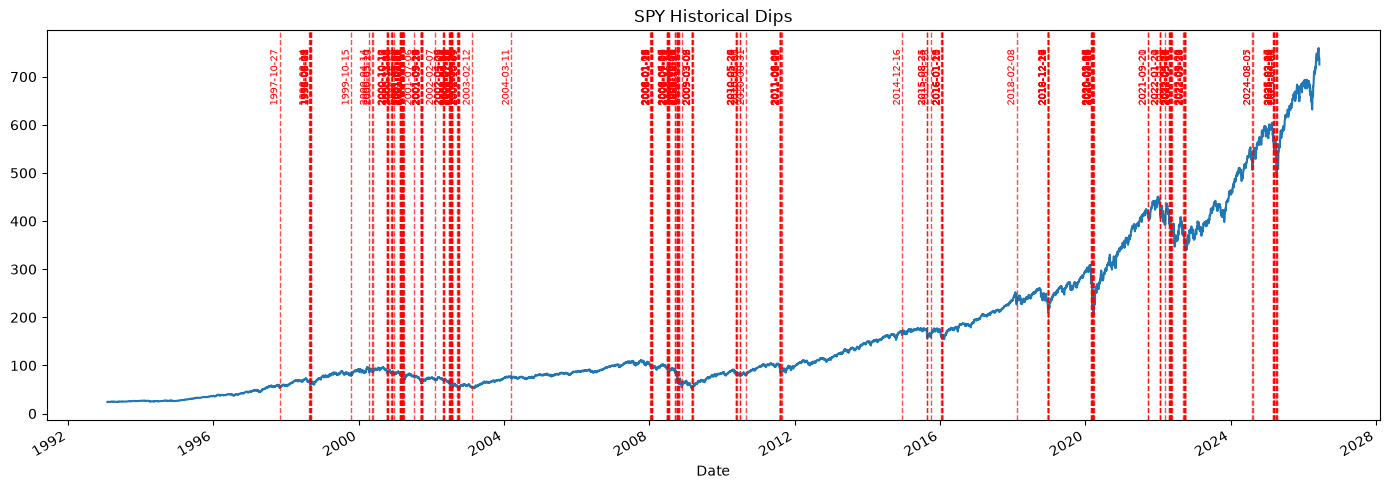

In [13]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(14, 5))
signal_df['Close'].plot(ax=ax, title='SPY Historical Dips')

for date in composite_points:
    ax.axvline(x=date, color='red', linestyle='--', alpha=0.7, linewidth=1)
    ax.text(date, ax.get_ylim()[1] * 0.95, date.strftime('%Y-%m-%d'),
            rotation=90, fontsize=7, color='red', ha='right', va='top')

plt.tight_layout()
plt.show()

In [ ]:
assert len(composite_points) > 0

last_composite_point = composite_points[0]
n_days_cooldown = 30 
pct_gain = 0.05 
n_days = 10 

close = signal_df['Close']

for c in candidate_dates:
    if (c - last_composite_point).days <= n_days_cooldown:
        continue
    last_composite_point = c

    pos = close.index.get_loc(c)
    if pos + n_days >= len(close):
        continue  # not enough future data

    ret = (close.iloc[pos + n_days] - close.iloc[pos]) / close.iloc[pos]

TypeError: Addition/subtraction of integers and integer-arrays with Timestamp is no longer supported.  Instead of adding/subtracting `n`, use `n * obj.freq`